### Day09 Regularization module [Cont.]

In [1]:
# import necessary libs.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

### Loading dataset ...

In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


### Splitting dataset for training and testing

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1].values,
                                                   df["target"],
                                                   random_state=42,
                                                   test_size=0.3)

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((309, 10), (133, 10), (309,), (133,))

Now that we got our dataset, it's time to apply `Lasso` regression on different `alpha` values. 

In [5]:
different_alpha_values = [ 0.5, 0.25, 0, 1, 5, 10 ]

r2_scores = []
coefficients = []

for alpha in different_alpha_values:
    lasso_regression = Lasso(alpha=alpha)

    # fit the model on training dataset
    lasso_regression.fit(X_train, y_train)

    # get the predictions
    predictions = lasso_regression.predict(X_test)

    # calculate r2_score
    score = r2_score(y_test, predictions)

    # append score and coef into list
    r2_scores.append(score)
    coefficients.append(list(lasso_regression.coef_))

C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\papsr\anaconda3\envs\dl\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.518e+05, tolerance: 1.900e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.e

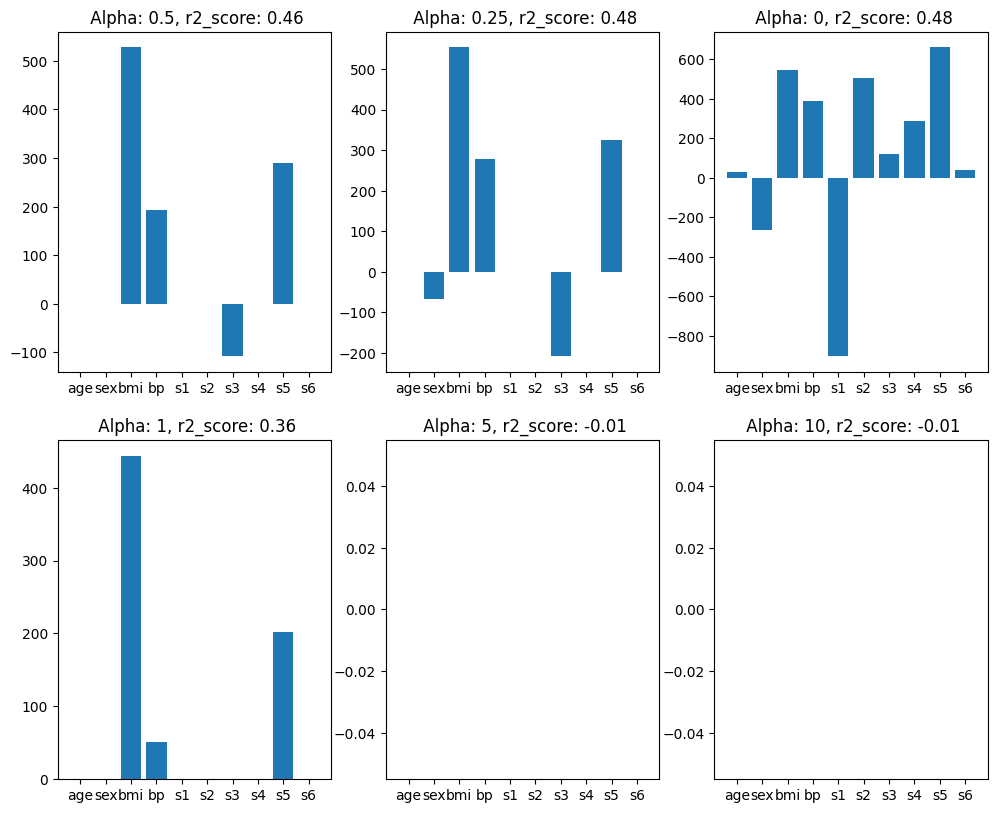

In [6]:
plt.figure(figsize=(12, 15))
for idx in range(len(coefficients)):
    plt.subplot(idx + 331)
    plt.bar(data.feature_names, coefficients[idx])
    plt.title(f" Alpha: {different_alpha_values[idx]}, r2_score: {r2_scores[idx]:.2f}")
plt.show()

From the above graph we can clearly see that, the greater the value of `alpha` in `Lasso` higher the chances of **sparsity** in the dataset.
<br/>
We can check that **sparsity** numerically in the below given table as well.

In [7]:
sparsity_df = pd.DataFrame( coefficients, columns=data.feature_names, index=pd.Index(different_alpha_values, name="alpha") )
sparsity_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
alpha,,,,,,,,,,
0.50,0.000000,-0.000000,527.787158,193.131492,-0.000000,-0.000000,-107.806486,0.000000,289.363030,0.000000
0.25,0.000000,-66.299335,553.435121,278.736946,-0.000000,-0.000000,-208.631671,0.000000,324.996165,0.000000
0.00,29.254013,-261.706469,546.299723,388.398341,-901.959664,506.763238,121.154349,288.035266,659.268949,41.376701
1.00,0.000000,-0.000000,443.703388,51.601094,0.000000,0.000000,-0.000000,0.000000,201.966478,0.000000
5.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
10.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
